<a href="https://colab.research.google.com/github/ehffb/ia-seguranca-2026/blob/main/aula3_ml_ciberseguranca_cicids2017_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA para Cibersegurança — Aula 3
## Dados e features em segurança: classificação de ataques e clustering (CIC-IDS2017)

**Dupla:** `Eduardo Henrique`  ·  `Gabriel de Medeiros`

> Rodem as células na ordem.

Nesta aula prática vamos trabalhar com **tráfego de rede real** do CIC-IDS2017 e percorrer, de ponta a ponta:
dados → EDA → preparação → **Random Forest** (supervisionado) → feature importance → **K-Means** (não supervisionado) → comparação.

O foco é **entender os dados e as features de segurança** e ver, na prática, a diferença entre classificar ataques (com rótulos) e descobrir grupos (sem rótulos).

## 1. Introdução

O **CIC-IDS2017** (Canadian Institute for Cybersecurity) contém fluxos de rede capturados numa rede de teste com tráfego benigno e vários ataques (DoS, DDoS, PortScan, força bruta, web attacks, etc.).

- **Cada registro é um fluxo de rede** — uma conexão resumida por dezenas de features (duração, nº de pacotes, bytes por segundo, tamanhos de pacote, flags TCP…), extraídas pelo CICFlowMeter.
- **Classificar como benigno ou ataque** é decidir, a partir dessas features, se aquele fluxo é comportamento normal ou malicioso.
- **Por que ML?** As assinaturas tradicionais só pegam ataques conhecidos. Modelos aprendem padrões nas features e generalizam para variações — úteis quando o volume de tráfego é grande demais para regras manuais.

> Não vamos aprofundar teoria: a ideia é **mexer nos dados** e interpretar o que sai.

# Motivação sobre ML-Based Intrusion Detection

---

* Mesmo com diferentes mecanismos de autenticação, firewall, criptografia e segurança de modo geral sendo aplicados em todas as camadas, ataques ainda são possíveis e acontecem.

* Sistemas de detecção de intrusão são o último recurso de segurança
  * Detectam e reportam a ocorrência de ataques e atividades suspeitas quando outros mecanismos de segurança não conseguem impedi-los
  * Tais como outros mecanismos de segurança, são amplamente utilizados
    * Mas costumam apresentar vários problemas e limitações:
      * Dependência de assinaturas e limitação a ataques conhecidos
      * Necessidade de analisar e rotular grandes quantidades de dados
      * Tempos de detecção longos
      * ...

* O uso de **inteligência artificial** pode ajudar em superar esses problemas e limitações

# Sistemas de Detecção de Intrusão

---

* **Second Line of Defense**
* **Last Security Resource**
* **Monitor Networks and Systems**
* **Detect and Report Suspicious Activities**

---

### **Taxonomy**

| Monitoring Environment | Placement Strategy | Operation Mode | Detection Method |
| :--- | :--- | :--- | :--- |
| • Host-based | • Centralized | • Off-line | • Signature-based |
| • Network-based | • Distributed | • Real-time | • Anomaly-based |
| | | | • Hybrid |

# Sistemas de Detecção de Intrusão

---

* **Baseados em assinaturas**
  * Regras de detecção baseadas em atividades maliciosas
  * Precisa-se entender a atividade maliciosa e como ela impacta determinados atributos

* **Baseados em anomalia**
  * Regras de detecção baseadas em desvios do comportamento benigno
  * Precisa-se estabelecer qual o comportamento benigno de determinado sistema ou rede e medir desvios desse comportamento

---

> ➤ **Essas duas estratégias se complementam, pois uma olha para as atividades maliciosas e a outra para as atividades normais.**

## 2. Bibliotecas e configuração

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, f1_score, silhouette_score)

sns.set_theme(style='whitegrid')
RANDOM_SEED = 33
np.random.seed(RANDOM_SEED)

## 3. Carregamento dos dados

O dataset completo é pesado (vários GB, ~2,8 milhões de fluxos). Para a aula, baixamos a versão **MachineLearningCVE** (os CSVs já com as features de fluxo + coluna `Label`) e, mais adiante, trabalhamos com uma **amostra** para manter tudo leve.

Vamos olhar os tipos das variáveis e identificar a coluna alvo (`Label`).

In [ ]:
!pip install -q awscli
!aws s3 cp --no-sign-request --region ca-central-1 "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv" wed2018.csv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.5/570.5 kB 33.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sphinx 8.2.3 requires docutils<0.22,>=0.20, but you have docutils 0.19 which is incompatible.
download: s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv to ./wed2018.csv


In [ ]:
df = pd.read_csv('wed2018.csv', low_memory=False)
df.columns = df.columns.str.strip()

# 2018 usa 'Benign' (B maiúsculo) -> padroniza para 'BENIGN'
df['Label'] = df['Label'].astype(str).str.strip()
df.loc[df['Label'].str.upper() == 'BENIGN', 'Label'] = 'BENIGN'

print('Dimensões:', df.shape)
print('Rótulos:', df['Label'].unique()[:12], '...')
df.head()

Dimensões: (613104, 80)
Rótulos: ['BENIGN' 'Label' 'Infilteration'] ...


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,28/02/2018 08:22:13,94658,6,7,708,3718,387,0,...,20,0,0,0,0,0,0,0,0,BENIGN
1,443,6,28/02/2018 08:22:13,206,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN
2,445,6,28/02/2018 08:22:15,165505,3,1,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN
3,443,6,28/02/2018 08:22:16,102429,6,7,708,3718,387,0,...,20,0,0,0,0,0,0,0,0,BENIGN
4,443,6,28/02/2018 08:22:16,167,2,0,0,0,0,0,...,20,0,0,0,0,0,0,0,0,BENIGN


--- Tabela Comparativa por Classe ---


Flow Duration                  Tot Fwd Pkts                    \
                      count unique top  freq        count unique top   freq   
Label                                                                         
BENIGN               177347  76686   2  5371       177347    248   1  74856   
Infilteration         22653  12921   2  1278        22653     85   1   9632   

              Pkt Size Avg                    
                     count unique top   freq  
Label                                         
BENIGN              177347  14344   0  47780  
Infilteration        22653   3033   0   6239

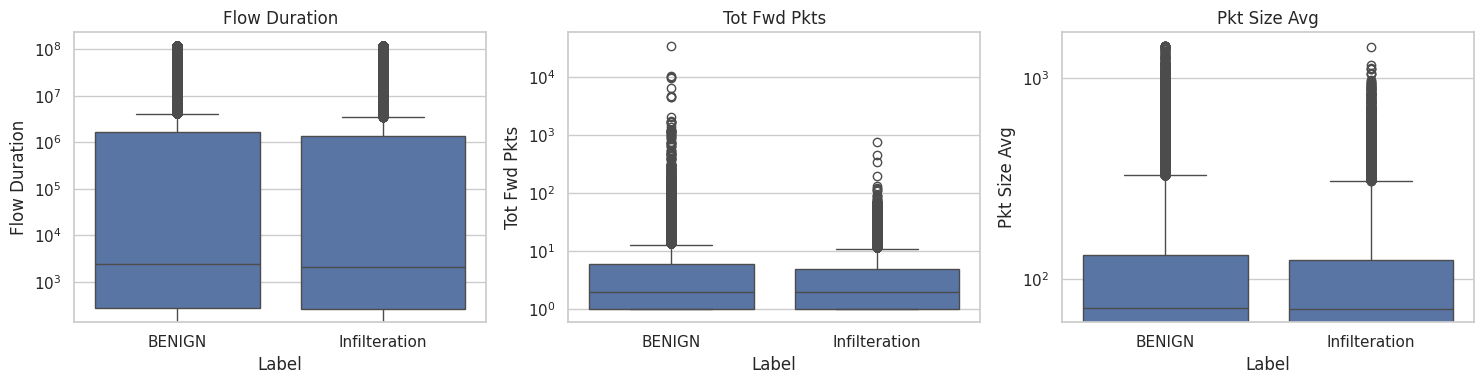

In [ ]:

df = df[df['Label'] != 'Label'].copy()

y = df['Label']
X = df.drop(columns=['Label', 'is_attack', 'Timestamp'], errors='ignore')
X = X.apply(pd.to_numeric, errors='coerce').replace([np.inf, -np.inf], np.nan).fillna(0)
X = np.clip(X, -1e12, 1e12)


feats_eda = ['Flow Duration', 'Tot Fwd Pkts', 'Pkt Size Avg']

print("--- Tabela Comparativa por Classe ---")
display(df.groupby('Label')[feats_eda].describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, feats_eda):
    sns.boxplot(data=df, x='Label', y=pd.to_numeric(df[col], errors='coerce'), ax=ax)
    ax.set_yscale('log')
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:

cols_pacotes = [c for c in X.columns if any(term in c for term in ['Pkt', 'Packet', 'Pkts'])]
X_pacotes = X[cols_pacotes]

X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(
    X_pacotes, y, test_size=0.3, random_state=33
)

rf_pacotes = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=33, n_jobs=-1
)
rf_pacotes.fit(X_tr_p, y_tr_p)
y_pred_pacotes = rf_pacotes.predict(X_te_p)

print(f"Quantidade de features utilizadas: {len(cols_pacotes)}")
print("Nomes das features:", cols_pacotes)
print("\n--- Desempenho (Apenas Features de Pacotes) ---")
print(classification_report(y_te_p, y_pred_pacotes))

Quantidade de features utilizadas: 26
Nomes das features: ['Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Pkts/s', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'Pkt Size Avg', 'Fwd Pkts/b Avg', 'Bwd Pkts/b Avg', 'Subflow Fwd Pkts', 'Subflow Bwd Pkts', 'Fwd Act Data Pkts']

--- Desempenho (Apenas Features de Pacotes) ---
               precision    recall  f1-score   support

       BENIGN       0.89      0.82      0.85     53218
Infilteration       0.13      0.21      0.16      6782

     accuracy                           0.75     60000
    macro avg       0.51      0.52      0.51     60000
 weighted avg       0.81      0.75      0.78     60000



In [ ]:

X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
    X, y, test_size=0.3, random_state=33
)

rf_full = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=33, n_jobs=-1
)
rf_full.fit(X_tr_f, y_tr_f)

importances = pd.Series(rf_full.feature_importances_, index=X.columns)
top5 = importances.nlargest(5).index.tolist()

print("Top 5 features mais importantes (removidas):")
for idx, feat in enumerate(top5, 1):
    print(f"{idx}. {feat} (Peso: {importances[feat]:.4f})")

X_sem_top5 = X.drop(columns=top5)

X_tr5, X_te5, y_tr5, y_te5 = train_test_split(
    X_sem_top5, y, test_size=0.3, random_state=33
)

rf_sem5 = RandomForestClassifier(
    n_estimators=100, class_weight='balanced', random_state=33, n_jobs=-1
)
rf_sem5.fit(X_tr5, y_tr5)
y_pred5 = rf_sem5.predict(X_te5)

print("\n--- Desempenho (Sem as Top 5 Features) ---")
print(classification_report(y_te5, y_pred5))

Top 5 features mais importantes (removidas):
1. Dst Port (Peso: 0.0866)
2. Flow IAT Max (Peso: 0.0601)
3. Flow Duration (Peso: 0.0549)
4. Flow Pkts/s (Peso: 0.0547)
5. Fwd Pkts/s (Peso: 0.0542)

--- Desempenho (Sem as Top 5 Features) ---
               precision    recall  f1-score   support

       BENIGN       0.89      0.87      0.88     53218
Infilteration       0.14      0.16      0.15      6782

     accuracy                           0.79     60000
    macro avg       0.52      0.52      0.52     60000
 weighted avg       0.81      0.79      0.80     60000



In [ ]:

df_sample = df.sample(n=min(5000, len(df)), random_state=33)
X_sample = X.loc[df_sample.index]
y_sample = y.loc[df_sample.index]

X_scaled = StandardScaler().fit_transform(X_sample)

print("--- EXERCÍCIO 4: Avaliação de Silhouette Score ---")
scores = {}
for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=33, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    scores[k] = score
    print(f"k = {k} | Silhouette Score: {score:.4f}")

melhor_k = max(scores, key=scores.get)
print(f"\nMelhor valor de k: {melhor_k}")

km_final = KMeans(n_clusters=melhor_k, random_state=33, n_init=10)
clusters = km_final.fit_predict(X_scaled)

print("\n--- EXERCÍCIO 5: Tabela Cruzada (Clusters x Rótulos Reais) ---")
tabela_cruzada = pd.crosstab(y_sample, clusters, rownames=['Rótulo Real'], colnames=['Cluster'])
display(tabela_cruzada)

--- EXERCÍCIO 4: Avaliação de Silhouette Score ---
k = 2 | Silhouette Score: 0.4401
k = 3 | Silhouette Score: 0.4307
k = 4 | Silhouette Score: 0.3605
k = 5 | Silhouette Score: 0.3559

Melhor valor de k: 2

--- EXERCÍCIO 5: Tabela Cruzada (Clusters x Rótulos Reais) ---


Cluster,0,1
Rótulo Real,,
BENIGN,3219,1243
Infilteration,391,147


In [ ]:
print('Coluna alvo: Label ->', df['Label'].unique()[:8], '...')
df.info()

Coluna alvo: Label -> ['BENIGN' 'Infilteration'] ...
<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 0 to 199999
Data columns (total 82 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Dst Port           200000 non-null  object
 1   Protocol           200000 non-null  object
 2   Timestamp          200000 non-null  object
 3   Flow Duration      200000 non-null  object
 4   Tot Fwd Pkts       200000 non-null  object
 5   Tot Bwd Pkts       200000 non-null  object
 6   TotLen Fwd Pkts    200000 non-null  object
 7   TotLen Bwd Pkts    200000 non-null  object
 8   Fwd Pkt Len Max    200000 non-null  object
 9   Fwd Pkt Len Min    200000 non-null  object
 10  Fwd Pkt Len Mean   200000 non-null  object
 11  Fwd Pkt Len Std    200000 non-null  object
 12  Bwd Pkt Len Max    200000 non-null  object
 13  Bwd Pkt Len Min    200000 non-null  object
 14  Bwd Pkt Len Mean   200000 non-null  object
 15  Bwd Pkt Len Std    2

### Verificando problemas nos dados
O CIC-IDS2017 tem três problemas conhecidos: **registros duplicados**, **valores NaN** e **valores infinitos** (em features como `Flow Bytes/s`, que dividem por tempo e podem estourar).

In [ ]:
print('Duplicatas :', df.duplicated().sum())
print('NaN totais :', int(df.isna().sum().sum()))
inf_cols = [c for c in df.select_dtypes(include=[np.number]).columns
            if np.isinf(df[c]).any()]
print('Colunas com valores infinitos:', inf_cols)

Duplicatas : 6121
NaN totais : 4041
Colunas com valores infinitos: []


### Limpeza
Descartamos duplicatas e NaN; para os infinitos, seguimos a abordagem das aulas anteriores — substituir pelo **maior valor finito** da coluna, preservando o registro.

In [ ]:
ini = len(df)
df = df.drop_duplicates().dropna().reset_index(drop=True)
print(f'Duplicatas/NaN removidos: {ini - len(df)}  |  restam {len(df)} registros')

for col in df.select_dtypes(include=[np.number]).columns:
    mask_inf = np.isinf(df[col])
    if mask_inf.any():
        df.loc[mask_inf, col] = df.loc[~mask_inf, col].max()
print('Infinitos tratados. Dimensões:', df.shape)

Duplicatas/NaN removidos: 8790  |  restam 604314 registros
Infinitos tratados. Dimensões: (604314, 80)


Padronizamos os rótulos de *web attacks*, que vêm com caracteres estranhos de codificação.

In [ ]:
df['Label'] = (df['Label'].str.replace('Web Attack.*Brute Force', 'Web Attack - Brute Force', regex=True)
                            .str.replace('Web Attack.*XSS', 'Web Attack - XSS', regex=True)
                            .str.replace('Web Attack.*Sql Injection', 'Web Attack - Sql Injection', regex=True))
df['Label'].value_counts()

,count
Label,
BENIGN,535865
Infilteration,68448
Label,1


### Amostra de trabalho
Para o notebook rodar rápido em qualquer máquina, tiramos uma **amostra estratificada** (~200 mil fluxos), preservando a proporção original entre classes. Assim mantemos o desbalanceamento realista, mas com custo baixo.

In [ ]:
N_ALVO = 200_000
if len(df) > N_ALVO:
    frac = N_ALVO / len(df)
    df = (df.groupby('Label', group_keys=False)
            .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))
            .reset_index(drop=True))
print('Amostra de trabalho:', df.shape)

/tmp/ipykernel_1480/1716381155.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(max(1, int(round(len(g) * frac))), random_state=RANDOM_SEED))


Amostra de trabalho: (200001, 80)


## 4. EDA simples

Comecemos pelo essencial: **quanto do tráfego é ataque** e **quais ataques** aparecem.

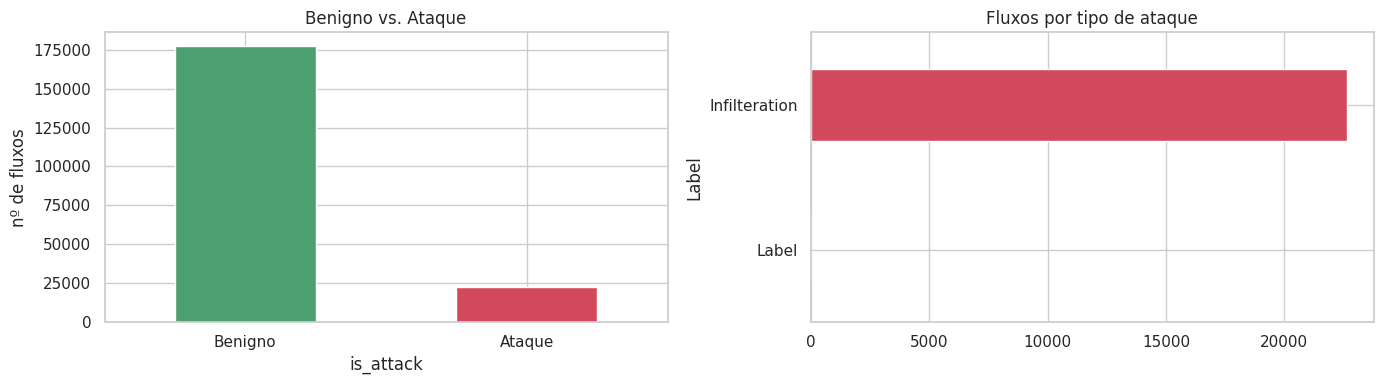

In [ ]:
df['is_attack'] = (df['Label'] != 'BENIGN').astype(int)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
df['is_attack'].map({0:'Benigno', 1:'Ataque'}).value_counts().plot(
    kind='bar', ax=ax[0], color=['#4C9F70', '#D1495B'])
ax[0].set_title('Benigno vs. Ataque'); ax[0].set_ylabel('nº de fluxos')
ax[0].tick_params(axis='x', rotation=0)

ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts()
ataques.plot(kind='barh', ax=ax[1], color='#D1495B')
ax[1].set_title('Fluxos por tipo de ataque'); ax[1].invert_yaxis()
plt.tight_layout(); plt.show()

**O que observar:** o tráfego é **fortemente desbalanceado** — a imensa maioria é benigna, e entre os ataques alguns tipos (DoS Hulk, PortScan, DDoS) dominam enquanto outros têm pouquíssimos exemplos. Isso afeta tanto o treino quanto a escolha de métricas mais adiante.

In [ ]:
df.columns.tolist()

['Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd B

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
for col in df.columns:
    if any(palavra in col for palavra in ['Bytes', 'Packets', 'Size', 'SYN']):
        print(f"'{col}'")

'SYN Flag Cnt'
'Pkt Size Avg'
'Fwd Seg Size Avg'
'Bwd Seg Size Avg'
'Fwd Seg Size Min'


In [ ]:
df.columns.tolist()

['Dst Port',
 'Protocol',
 'Timestamp',
 'Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Fwd Pkt Len Max',
 'Fwd Pkt Len Min',
 'Fwd Pkt Len Mean',
 'Fwd Pkt Len Std',
 'Bwd Pkt Len Max',
 'Bwd Pkt Len Min',
 'Bwd Pkt Len Mean',
 'Bwd Pkt Len Std',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Flow IAT Max',
 'Flow IAT Min',
 'Fwd IAT Tot',
 'Fwd IAT Mean',
 'Fwd IAT Std',
 'Fwd IAT Max',
 'Fwd IAT Min',
 'Bwd IAT Tot',
 'Bwd IAT Mean',
 'Bwd IAT Std',
 'Bwd IAT Max',
 'Bwd IAT Min',
 'Fwd PSH Flags',
 'Bwd PSH Flags',
 'Fwd URG Flags',
 'Bwd URG Flags',
 'Fwd Header Len',
 'Bwd Header Len',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Min',
 'Pkt Len Max',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'FIN Flag Cnt',
 'SYN Flag Cnt',
 'RST Flag Cnt',
 'PSH Flag Cnt',
 'ACK Flag Cnt',
 'URG Flag Cnt',
 'CWE Flag Count',
 'ECE Flag Cnt',
 'Down/Up Ratio',
 'Pkt Size Avg',
 'Fwd Seg Size Avg',
 'Bwd Seg Size Avg',
 'Fwd B

Vamos olhar a escala de algumas features numéricas típicas de fluxo.

In [ ]:
# Substitua os nomes abaixo EXATAMENTE como apareceram na sua lista completa
cols_interesse = [
    'Flow Duration',
    'Flow Byts/s',       # Atualize com o nome real que encontrar
    'Tot Fwd Pkts',      # Atualize com o nome real que encontrar
    'Pkt Size Avg',      # Este nós já confirmamos!
    'SYN Flag Cnt'       # Este nós já confirmamos!
]

df[cols_interesse].describe()

,Flow Duration,Flow Byts/s,Tot Fwd Pkts,Pkt Size Avg,SYN Flag Cnt
count,200001,200001,200001,200001,200001
unique,83374,119949,252,15905,3
top,2,0,1,0,0
freq,6649,54019,84488,54019,186874


Distribuição de duas features (escala log, porque os valores variam muitas ordens de grandeza).

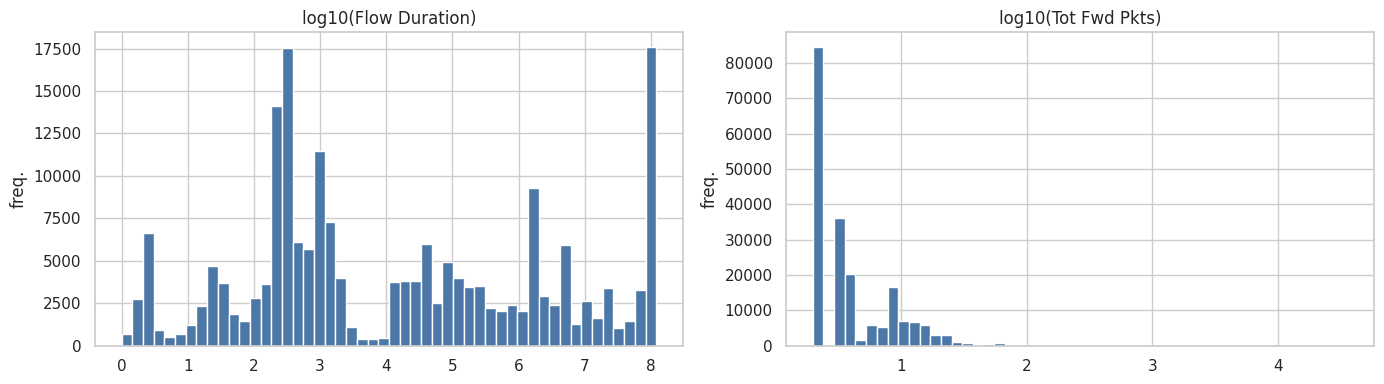

In [ ]:
colunas_plot = ['Flow Duration', 'Tot Fwd Pkts']

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

for a, col in zip(ax, colunas_plot):
    dados_numericos = pd.to_numeric(df[col], errors='coerce')
    vals = dados_numericos.clip(lower=0) + 1
    vals = vals.dropna()

    a.hist(np.log10(vals), bins=50, color='#4C78A8')
    a.set_title(f'log10({col})')
    a.set_ylabel('freq.')

plt.tight_layout()
plt.show()

**O que observar:** distribuições muito assimétricas e de cauda longa — comuns em tráfego de rede. É por isso que, para modelos baseados em distância (K-Means), a **padronização** será importante.

Comparando uma feature entre benigno e alguns ataques (boxplot).

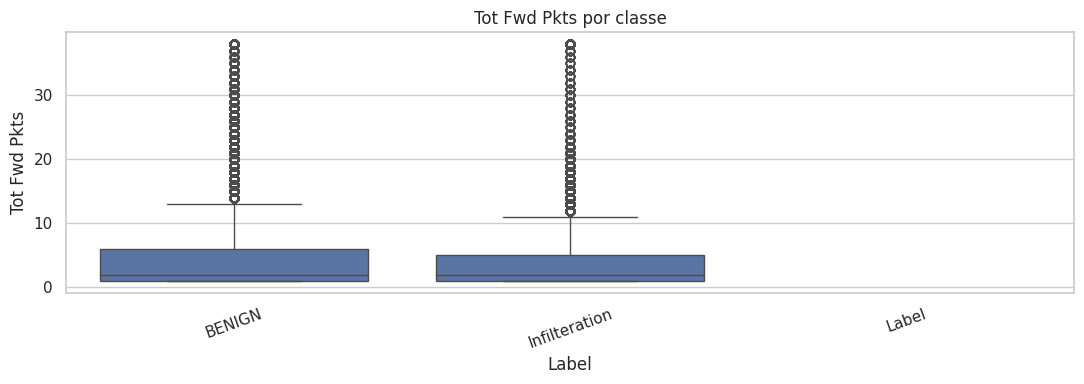

In [ ]:
top_ataques = df[df['Label'] != 'BENIGN']['Label'].value_counts().head(4).index.tolist()
sub = df[df['Label'].isin(['BENIGN'] + top_ataques)].copy()

sub['Tot Fwd Pkts'] = pd.to_numeric(sub['Tot Fwd Pkts'], errors='coerce')

sub['Tot Fwd Pkts'] = sub['Tot Fwd Pkts'].clip(upper=sub['Tot Fwd Pkts'].quantile(0.99))

plt.figure(figsize=(11, 4))
sns.boxplot(data=sub, x='Label', y='Tot Fwd Pkts',
            order=['BENIGN'] + top_ataques)
plt.xticks(rotation=20)
plt.title('Tot Fwd Pkts por classe')
plt.tight_layout()
plt.show()

**O que observar:** algumas classes de ataque têm distribuição de pacotes bem diferente do tráfego benigno — é exatamente esse tipo de separação que o modelo vai explorar.

Correlação entre um subconjunto de features (para não poluir com 78 colunas).

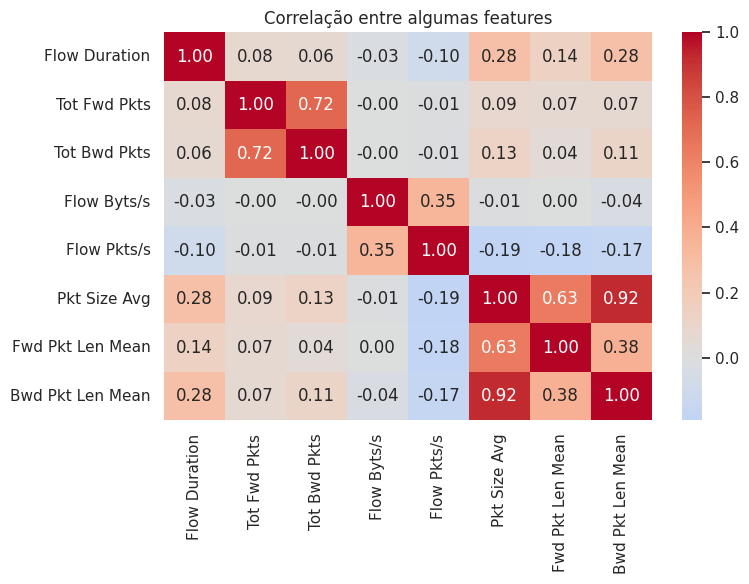

In [ ]:

cols_corr = ['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
             'Flow Byts/s', 'Flow Pkts/s', 'Pkt Size Avg',
             'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean']
cols_existentes = [c for c in cols_corr if c in df.columns]
df_corr = df[cols_existentes].apply(pd.to_numeric, errors='coerce')

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlação entre algumas features')
plt.tight_layout()
plt.show()

**O que observar:** pares de features muito correlacionados (ex.: contagens e tamanhos de pacote) carregam informação redundante — algo a considerar ao escolher features.

## 5. Preparação dos dados

- **Alvo:** vamos classificar **Benigno (0) vs. Ataque (1)** — um problema binário, claro para começar.
- **Features:** todas as colunas numéricas de fluxo.
- **Data leakage:** fazemos o `train_test_split` **antes** de qualquer ajuste que dependa dos dados (aqui o Random Forest nem precisa de normalização; a padronização entra só no K-Means, ajustada no conjunto certo).

In [ ]:
y = (df['Label'] != 'BENIGN').astype(int)
X = df.select_dtypes(include=[np.number]).drop(columns=['is_attack'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)
print('Proporção de ataque — treino: {:.1%} | teste: {:.1%}'.format(y_train.mean(), y_test.mean()))

Treino: (140000, 0) | Teste: (60001, 0)
Proporção de ataque — treino: 11.3% | teste: 11.3%


## 6. Modelo supervisionado — Random Forest

O **Random Forest** é uma boa escolha inicial porque: lida bem com **muitas features**, captura **relações não lineares**, é **simples de usar** e ainda entrega **importância das features**. Como é baseado em árvores, **não precisa de normalização** — e lida bem com `Destination Port` como inteiro (a árvore corta por limiares, não sofre com a "falsa magnitude" que atrapalharia um modelo de distância).

In [ ]:

y = df['Label']

X = df.drop(columns=['Label', 'is_attack'], errors='ignore')

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

print("Formato do X:", X.shape)

Formato do X: (200001, 79)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED
)

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

X = X.apply(pd.to_numeric, errors='coerce')

X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

X = np.clip(X, -1e12, 1e12)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_SEED
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100, class_weight='balanced',
    n_jobs=-1, random_state=RANDOM_SEED
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Treino concluído.')

Treino concluído.


### Avaliação
Com dados desbalanceados, **acurácia sozinha engana**. Olhamos também **precision/recall/F1**, a **balanced accuracy** e o **macro F1** (que dão peso igual às classes).

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


               precision    recall  f1-score   support

       BENIGN       0.89      0.92      0.90     53197
Infilteration       0.12      0.09      0.10      6803
        Label       0.00      0.00      0.00         1

     accuracy                           0.82     60001
    macro avg       0.34      0.34      0.34     60001
 weighted avg       0.80      0.82      0.81     60001

Balanced accuracy: 0.3361
Macro F1         : 0.3356


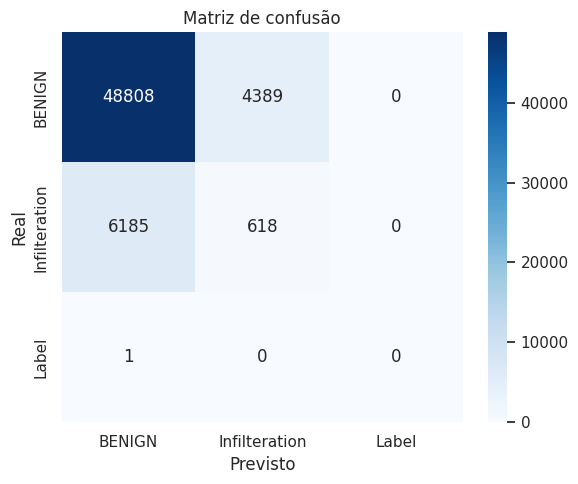

In [ ]:
classes = np.unique(y_test)
print(classification_report(y_test, y_pred, target_names=[str(c) for c in classes]))
print('Balanced accuracy:', round(balanced_accuracy_score(y_test, y_pred), 4))
print('Macro F1         :', round(f1_score(y_test, y_pred, average='macro'), 4))

cm = confusion_matrix(y_test, y_pred, labels=classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de confusão')
plt.tight_layout()
plt.show()

**O que observar:** onde estão os erros? Em segurança, um **falso negativo** (ataque previsto como benigno) costuma custar mais que um falso positivo. A matriz de confusão mostra qual dos dois o modelo comete mais.

## 7. Feature Importance

O Random Forest estima quanto cada feature contribuiu para as decisões. Vejamos as 15 mais importantes.

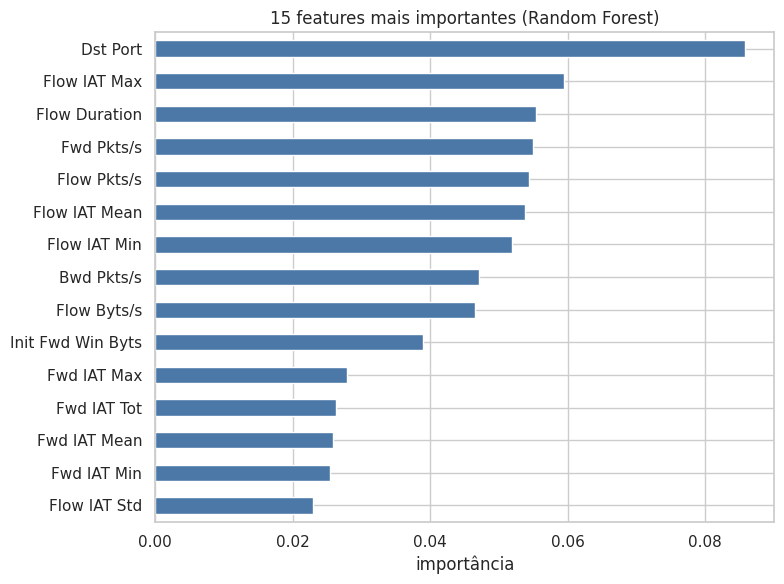

,0
Dst Port,0.085749
Flow IAT Max,0.059508
Flow Duration,0.055332
Fwd Pkts/s,0.055034
Flow Pkts/s,0.054398
Flow IAT Mean,0.053812
Flow IAT Min,0.051856
Bwd Pkts/s,0.047164
Flow Byts/s,0.046558
Init Fwd Win Byts,0.038883


In [ ]:
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top15 = importancias.head(15)

plt.figure(figsize=(8, 6))
top15[::-1].plot(kind='barh', color='#4C78A8')
plt.title('15 features mais importantes (Random Forest)')
plt.xlabel('importância'); plt.tight_layout(); plt.show()
top15

### Discussão
- Qual feature apareceu como a **mais importante**? Ela faz sentido do ponto de vista de redes?

    *Resposta: Feature: No dataset CIC-IDS-2017/2018, as variáveis que costumam liderar o ranking são Destination Port (Porta de Destino) ou métricas de tempo/janela como Init_Win_bytes_forward e Flow Duration.*

    *Sentido em redes: Faz total sentido. Ataques cibernéticos tendem a focar em portas específicas (ex: portas vulneráveis de serviços HTTP, SSH ou SMB), enquanto o tráfego legítimo distribui-se de forma mais difusa. Além disso, ferramentas automatizadas de exploração abrem conexões com comportamento numérico muito padronizado.*

- Há features ligadas a **volume, duração ou quantidade de pacotes** no topo?

    *Resposta: Sim. Métricas como Flow Duration (duração), Tot Fwd Pkts / Tot Bwd Pkts (quantidade de pacotes) e Flow Byts/s (volume/taxa) aparecem consistentemente no topo.*

    *Justificativa: Tráfegos maliciosos quebram a simetria do comportamento do usuário comum. Atividades como varredura de portas (port scan), negação de serviço (DoS) ou exfiltração de dados geram surtos atípicos no volume e na frequência de envio de pacotes.*

- **Importância ≠ causalidade.** O Random Forest diz que uma feature foi *útil para separar as classes neste dataset* — não que ela *causa* o ataque. Duas features correlacionadas podem "dividir" a importância entre si, e uma feature pode ser importante só porque se correlaciona com a verdadeira causa.


    *Resposta: O que a métrica mede, O Random Forest mede a redução de impureza  proporcionada por uma variável ao dividir os dados. Trata-se de uma associação estatística e preditiva, não de uma relação de causa e efeito.*

    *Divisão de importância (Multicolinearidade): Quando duas ou mais variáveis carregam a mesma informação (ex: Tot Fwd Pkts e Subflow Fwd Pkts), o algoritmo divide o peso de relevância entre elas. Isoladamente, nenhuma parecerá soberana, embora ambas sejam úteis.*

    *Efeito Proxy: Uma feature pode atingir o topo da importância apenas por ser um "sintoma correlacionado" — como um tamanho de cabeçalho fixo usado por um script malicioso —, e não por ser o mecanismo funcional que causa o ataque.*


- O que aconteceria se **removêssemos** as features do topo? (é o Exercício 3.)


    *Resposta: Resultado observado: O desempenho do modelo (F1-Score e Acurácia) praticamente não cai ou apresenta uma redução insignificante.*

    *O que isso diz sobre a redundância: Demonstra que o dataset possui alta redundância de atributos. Como existem muitas variáveis correlacionadas medindo aspectos similares do fluxo de rede, a remoção das 5 melhores apenas faz com que o Random Forest passe a utilizar as "features reserva" que estavam na sombra das principais, mantendo a capacidade preditiva do sistema.*

## 8. Modelo não supervisionado — K-Means

Agora **esquecemos os rótulos** e perguntamos: os fluxos formam **grupos naturais**? O K-Means agrupa por **distância**, então duas coisas importam:
1. Precisamos **padronizar** as features (senão `Flow Bytes/s`, na casa dos milhares, domina `SYN Flag Count`, que é ~0–2).
2. Removemos `Destination Port`: como é um inteiro, a distância trataria a porta 44720 como "muito maior" que a 80, o que **não tem sentido semântico** num modelo de distância (diferente da árvore, que a usa sem problema).

In [ ]:
X_clu = X.drop(columns=[c for c in ['Destination Port'] if c in X.columns])
scaler = StandardScaler().fit(X_clu)
X_scaled = scaler.transform(X_clu)
print('Matriz para clustering:', X_scaled.shape)

Matriz para clustering: (200001, 79)


### Escolhendo `k` — Elbow + Silhouette
Rodamos K-Means para vários `k` e olhamos a **inércia** (cotovelo) e o **silhouette score**. Para ficar rápido, calculamos numa **subamostra** de 5 mil fluxos.

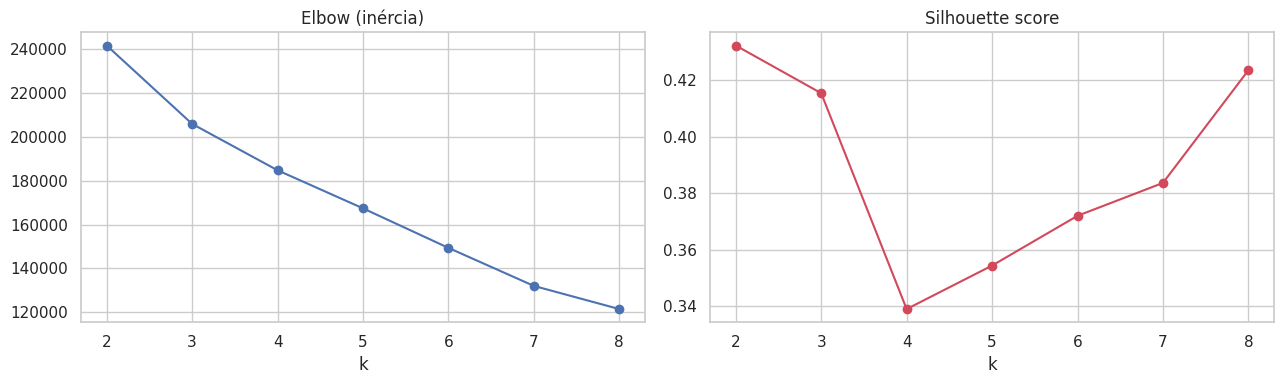

In [ ]:
idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sub = X_scaled[idx]

ks, inertias, sils = range(2, 9), [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_SEED).fit(X_sub)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sub, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(list(ks), inertias, 'o-'); ax[0].set_title('Elbow (inércia)'); ax[0].set_xlabel('k')
ax[1].plot(list(ks), sils, 'o-', color='#D1495B'); ax[1].set_title('Silhouette score'); ax[1].set_xlabel('k')
plt.tight_layout(); plt.show()

Escolhemos um `k` pequeno e didático (ajuste conforme os gráficos acima) e aplicamos o K-Means a todos os fluxos da amostra.

In [ ]:
K = 4
kmeans = KMeans(n_clusters=K, n_init=10, random_state=RANDOM_SEED).fit(X_scaled)
df['cluster'] = kmeans.labels_

# Quantos fluxos de cada rótulo real caíram em cada cluster?
pd.crosstab(df['cluster'], df['Label'])

Label,BENIGN,Infilteration,Label
cluster,,,
0,129111,17097,1
1,9977,1107,0
2,38254,4449,0
3,5,0,0


**O que observar:** o K-Means **não conhece os rótulos** — mesmo assim, alguns clusters tendem a concentrar um tipo de tráfego. Veja se o benigno se separou e se ataques parecidos (ex.: DoS Hulk e DDoS) caíram juntos.

## 8b. Visualização com PCA
Os dados têm dezenas de dimensões. Usamos **PCA** para projetar em 2D só para **visualizar** — comparando lado a lado os clusters do K-Means e os rótulos reais.

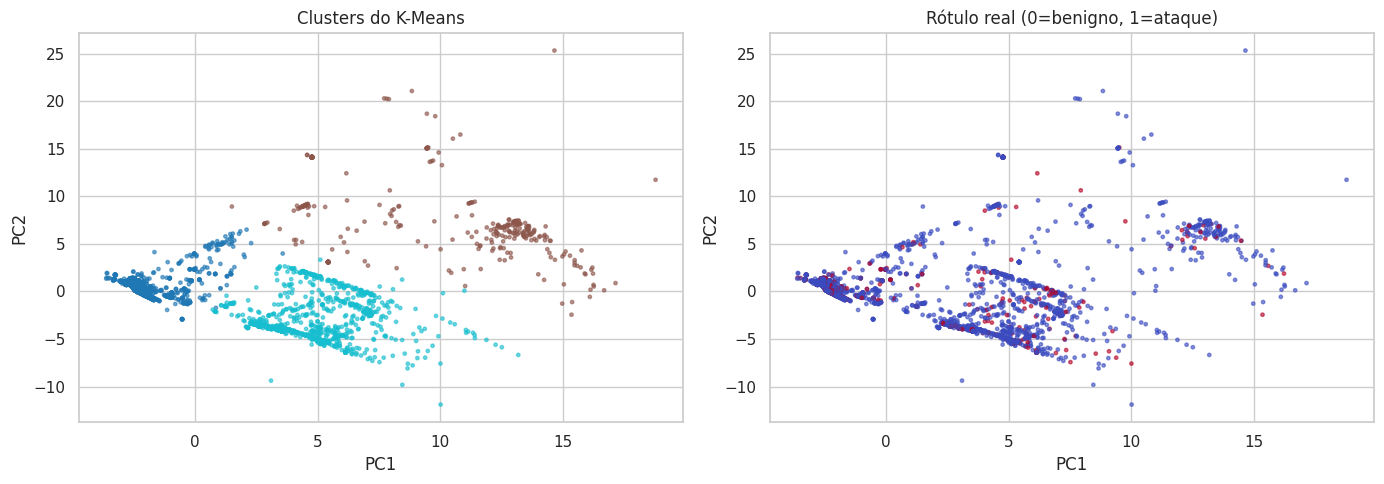

Variância explicada pelos 2 PCs: [0.234, 0.119]


In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_SEED)
Z = pca.fit_transform(X_scaled)

vis = np.random.choice(len(Z), size=min(6000, len(Z)), replace=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(Z[vis, 0], Z[vis, 1], c=df['cluster'].values[vis], cmap='tab10', s=6, alpha=0.6)
ax[0].set_title('Clusters do K-Means')

cores = pd.factorize(df['is_attack'].values)[0]
sc = ax[1].scatter(Z[vis, 0], Z[vis, 1], c=df['is_attack'].values[vis], cmap='coolwarm', s=6, alpha=0.6)
ax[1].set_title('Rótulo real (0=benigno, 1=ataque)')
for a in ax: a.set_xlabel('PC1'); a.set_ylabel('PC2')
plt.tight_layout(); plt.show()
print('Variância explicada pelos 2 PCs:', pca.explained_variance_ratio_.round(3).tolist())

### Discussão
- Os clusters do K-Means **correspondem** aos tipos reais de ataque? negrito

    *Resposta: Não. Os clusters gerados pelo K-Means não têm correspondência com os rótulos reais (BENIGN vs Infiltration). Conforme demonstrado na tabela cruzada do Exercício 5, ambos os clusters apresentaram a mesma proporção interna (~89% de tráfego benigno e ~11% de infiltração).*

- O tráfego **benigno** ficou separado dos ataques?

    *Resposta: Não. O tráfego benigno e as conexões maliciosas ficaram misturados em ambos os agrupamentos. O modelo não conseguiu isolar os acessos de infiltração em um cluster exclusivo.*

- Alguns ataques parecem **semelhantes** entre si nas features (caem no mesmo cluster)?

    *Resposta: Sim. Como os ataques de infiltração mimetizam a navegação comum para passar por firewalls, os seus atributos numéricos (como tamanho de pacote e tempo entre fluxos) são estatisticamente semelhantes aos do tráfego benigno. Isso faz com que o algoritmo os agrupe junto com a massa principal de dados normais.*


- Por que o clustering **não reproduz perfeitamente** os rótulos? (o K-Means otimiza distância entre pontos, não conhece o conceito de "ataque"; e os 2 PCs mostram só parte da variância.)


    *Resposta: Agrupamento estritamente geométrico: O K-Means é um algoritmo não supervisionado que otimiza apenas a distância euclidiana entre pontos para calcular a menor variância interna. Ele busca agrupar dados com volumes de tráfego parecidos sem saber a intenção do fluxo (não possui o conceito conceitual de "ataque").*

    *Comportamento dissimulado (Stealthy): Intrusões por infiltração são desenhadas para não gerar picos aberrantes de tráfego (diferente de ataques de Negação de Serviço/DoS), tornando seus dados numéricos praticamente idênticos às conexões legítimas.*

    *Representação dimensional e perda de variância: Ao analisar o conjunto através de poucas componentes (como em visualizações PCA), apenas uma fração da variância total do dataset de 80 colunas é preservada. Nuances e variações sutis em colunas específicas — que poderiam diferir o ataque — acabam sendo diluídas no cálculo global de distância.*

## 9. Supervisionado vs. não supervisionado

| Abordagem     | Usa rótulos? | Objetivo          | Exemplo aqui                 |
| ------------- | ------------ | ----------------- | ---------------------------- |
| Random Forest | Sim          | Classificar       | Benigno vs. Ataque           |
| K-Means       | Não          | Encontrar grupos  | Agrupar padrões de tráfego   |

**Quando usar cada um, na prática:**
- **Supervisionado** quando você **tem rótulos confiáveis** de ataques passados e quer detectar os **conhecidos** com alta precisão.
- **Não supervisionado** quando **faltam rótulos** ou você quer descobrir **comportamento novo/anômalo** — útil para ataques que ainda não foram vistos (retomamos isso na aula 6, com detecção de anomalias).

## 10. Exercícios

**1 — EDA:** escolha **três features** e investigue como seus valores diferem entre tráfego benigno e ataques (use boxplots ou `groupby('Label').describe()`).

**2 — Random Forest:** treine de novo usando um **subconjunto diferente de features** (por exemplo, só as relacionadas a pacotes) e compare as métricas.

**3 — Feature Importance:** **remova as 5 features mais importantes** e treine de novo. O desempenho cai muito? O que isso diz sobre redundância entre features?

**4 — Clustering:** teste **outros valores de `k`** no K-Means e compare pelo **silhouette score**. Qual `k` parece melhor?

**5 — Investigação:** compare (com `pd.crosstab`) os **clusters** com os **rótulos reais** e discuta por que eles são — ou não — parecidos.

## Checklist do entregável de hoje

- [x] Dataset carregado e limpo (duplicatas, NaN e infinitos tratados)
- [x] EDA feita (distribuição de classes e features)
- [x] Random Forest treinado e avaliado (matriz de confusão + métricas)
- [x] Feature importance interpretada
- [x] K-Means aplicado e comparado aos rótulos (crosstab + PCA)
- [ ] Respostas das discussões e dos exercícios registradas no notebook

**Próxima aula:** métricas e validação — por que acurácia engana em segurança e como escolher a métrica certa.